In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/MyDrive/UsedCarsSA_Clean_EN.csv'
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Mounted at /content/drive
Dataset Shape: (8035, 13)

First 5 rows:
       Make     Type  Year Origin   Color    Options  Engine_Size Fuel_Type  \
0  Chrysler     C300  2018  Saudi   Black       Full          5.7       Gas   
1    Nissan   Patrol  2016  Saudi   White       Full          4.8       Gas   
2    Nissan    Sunny  2019  Saudi  Silver   Standard          1.5       Gas   
3   Hyundai  Elantra  2019  Saudi    Grey   Standard          1.6       Gas   
4   Hyundai  Elantra  2019  Saudi  Silver  Semi Full          2.0       Gas   

   Gear_Type  Mileage  Region   Price  Negotiable  
0  Automatic   103000  Riyadh  114000       False  
1  Automatic     5448  Riyadh       0        True  
2  Automatic    72418  Riyadh   27500       False  
3  Automatic   114154  Riyadh   43000       False  
4  Automatic    41912  Riyadh   59500       False  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8035 entries, 0 to 8034
Data columns (total 13 columns):
 #   Column       Non-Nu

In [2]:
# Step 1: Data Cleaning
df_clean = df.copy()

# Remove rows with Price = 0 (negotiable/unspecified prices)
initial_shape = df_clean.shape[0]
df_clean = df_clean[df_clean['Price'] > 0]
print(f"Removed {initial_shape - df_clean.shape[0]} rows with Price = 0")

# Remove rows with unrealistic Mileage (> 500,000 km)
df_clean = df_clean[df_clean['Mileage'] <= 500000]

# Remove rows with unrealistic Engine_Size (> 10.0 L or < 0.5 L)
df_clean = df_clean[(df_clean['Engine_Size'] >= 0.8) & (df_clean['Engine_Size'] <= 8.0)]

# Remove rows with Year less than 1990 (too old)
df_clean = df_clean[df_clean['Year'] >= 1990]

# Remove extreme price outliers (top 1% and bottom 1%)
price_lower = df_clean['Price'].quantile(0.01)
price_upper = df_clean['Price'].quantile(0.99)
df_clean = df_clean[(df_clean['Price'] >= price_lower) & (df_clean['Price'] <= price_upper)]

print(f"Dataset after cleaning: {df_clean.shape}")

Removed 2527 rows with Price = 0
Dataset after cleaning: (5295, 13)


In [3]:
# Step 2: Feature Engineering
df_features = df_clean.copy()

# Create Car Age feature
df_features['Car_Age'] = 2026 - df_features['Year']

# Create log transformations for skewed features
df_features['Log_Mileage'] = np.log1p(df_features['Mileage'])
df_features['Log_Price'] = np.log1p(df_features['Price'])

# Convert Negotiable to binary
df_features['Is_Negotiable'] = df_features['Negotiable'].astype(int)

# Encode Options as ordinal
options_map = {'Standard': 0, 'Semi Full': 1, 'Full': 2}
df_features['Options_Encoded'] = df_features['Options'].map(options_map)

# Create Make_Type combined feature
df_features['Make_Type'] = df_features['Make'] + '_' + df_features['Type']

# Group rare colors into 'Other'
color_counts = df_features['Color'].value_counts()
rare_colors = color_counts[color_counts < 30].index.tolist()
df_features['Color_Group'] = df_features['Color'].apply(lambda x: 'Other' if x in rare_colors else x)

# Create Color groups based on perception
def categorize_color(color):
    dark_colors = ['Black', 'Grey', 'Navy', 'Brown', 'Bronze']
    bright_colors = ['Red', 'Blue', 'Green', 'Yellow', 'Orange']
    neutral_colors = ['White', 'Silver', 'Golden']

    if color in dark_colors:
        return 'Dark'
    elif color in bright_colors:
        return 'Bright'
    elif color in neutral_colors:
        return 'Neutral'
    else:
        return 'Other'

df_features['Color_Category'] = df_features['Color'].apply(categorize_color)

print("Feature Engineering Complete")
print(f"Features shape: {df_features.shape}")

Feature Engineering Complete
Features shape: (5295, 21)


In [4]:
# Step 3: Prepare features for modeling
# Select features for modeling
feature_columns = [
    'Car_Age', 'Log_Mileage', 'Engine_Size', 'Options_Encoded',
    'Is_Negotiable', 'Make', 'Type', 'Region', 'Origin',
    'Fuel_Type', 'Gear_Type', 'Color_Category', 'Make_Type'
]

# Create feature matrix X and target y
X = df_features[feature_columns].copy()
y = df_features['Log_Price'].copy()  # Using log-transformed price

# Encode categorical variables
categorical_columns = ['Make', 'Type', 'Region', 'Origin', 'Fuel_Type', 'Gear_Type', 'Color_Category', 'Make_Type']

# Apply Label Encoding for high-cardinality features
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("Categorical encoding complete")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Categorical encoding complete
Features shape: (5295, 13)
Target shape: (5295,)


In [5]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# Scale numerical features
numerical_columns = ['Car_Age', 'Log_Mileage', 'Engine_Size']
scaler = StandardScaler()
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_val[numerical_columns] = scaler.transform(X_val[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

Training set: (3825, 13)
Validation set: (675, 13)
Test set: (795, 13)


In [6]:
# Step 5: Model Training - XGBoost (Primary Model)
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False # Set verbose to False to suppress output during training, if supported
)

# Make predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_val = xgb_model.predict(X_val)
y_pred_test = xgb_model.predict(X_test)

# Convert back from log scale
y_train_actual = np.expm1(y_train)
y_val_actual = np.expm1(y_val)
y_test_actual = np.expm1(y_test)
y_pred_train_actual = np.expm1(y_pred_train)
y_pred_val_actual = np.expm1(y_pred_val)
y_pred_test_actual = np.expm1(y_pred_test)

# Calculate metrics
def evaluate_model(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{dataset_name} Results:")
    print(f"MAE: {mae:,.2f} SAR")
    print(f"RMSE: {rmse:,.2f} SAR")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    return mae, rmse, r2, mape

print("=== XGBoost Model Performance ===")
evaluate_model(y_train_actual, y_pred_train_actual, "Training")
evaluate_model(y_val_actual, y_pred_val_actual, "Validation")
evaluate_model(y_test_actual, y_pred_test_actual, "Test")

=== XGBoost Model Performance ===

Training Results:
MAE: 4,182.42 SAR
RMSE: 7,197.83 SAR
R² Score: 0.9857
MAPE: 5.87%

Validation Results:
MAE: 12,949.30 SAR
RMSE: 23,423.49 SAR
R² Score: 0.8324
MAPE: 32.42%

Test Results:
MAE: 13,515.84 SAR
RMSE: 24,636.31 SAR
R² Score: 0.8222
MAPE: 43.75%


(13515.835467030272,
 np.float64(24636.305371764058),
 0.8221786194412917,
 np.float64(43.75465762937898))

In [7]:
# Step 6: Train LightGBM as secondary model
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Train the model
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(30)])

# Make predictions
y_pred_test_lgb = lgb_model.predict(X_test)
y_pred_test_lgb_actual = np.expm1(y_pred_test_lgb)

print("\n=== LightGBM Model Performance ===")
evaluate_model(y_test_actual, y_pred_test_lgb_actual, "Test")

Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[275]	valid_0's l2: 0.124711

=== LightGBM Model Performance ===

Test Results:
MAE: 13,815.73 SAR
RMSE: 24,861.68 SAR
R² Score: 0.8189
MAPE: 42.23%


(13815.734779180895,
 np.float64(24861.679512313443),
 0.8189103005613638,
 np.float64(42.226115473601))

In [8]:
# Step 7: Ensemble Model (Average of XGBoost and LightGBM)
y_pred_ensemble = (y_pred_test + y_pred_test_lgb) / 2
y_pred_ensemble_actual = np.expm1(y_pred_ensemble)

print("\n=== Ensemble Model Performance (XGBoost + LightGBM) ===")
evaluate_model(y_test_actual, y_pred_ensemble_actual, "Test")


=== Ensemble Model Performance (XGBoost + LightGBM) ===

Test Results:
MAE: 13,346.80 SAR
RMSE: 24,316.28 SAR
R² Score: 0.8268
MAPE: 42.37%


(13346.802237496879,
 np.float64(24316.28040122064),
 0.8267684042454555,
 np.float64(42.369872594044324))


Top 10 Most Important Features (XGBoost):
            Feature  Importance
2       Engine_Size    0.169944
0           Car_Age    0.152664
3   Options_Encoded    0.115279
5              Make    0.100402
12        Make_Type    0.084405
10        Gear_Type    0.079421
9         Fuel_Type    0.067256
1       Log_Mileage    0.061187
6              Type    0.054272
8            Origin    0.049489


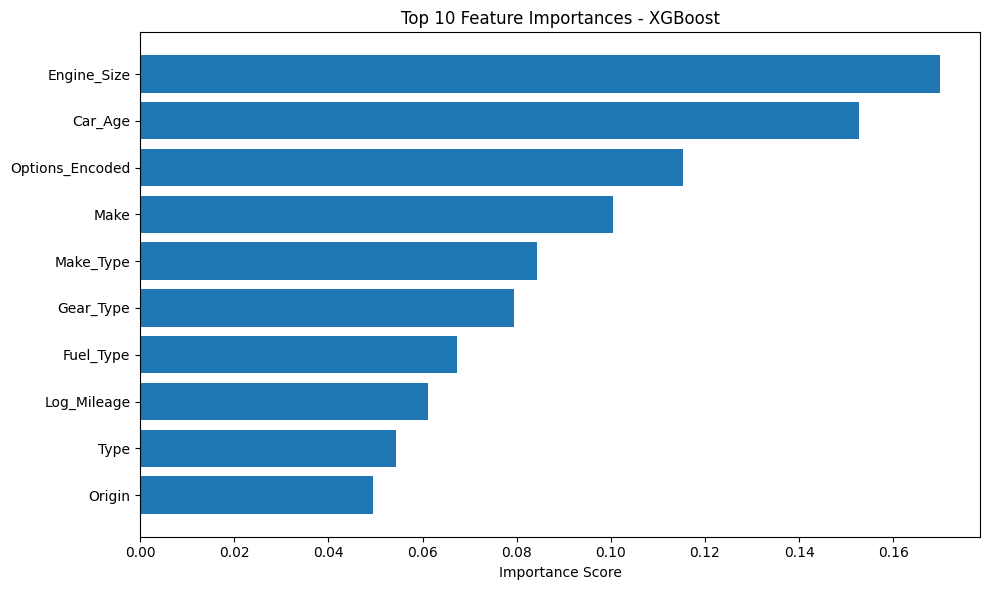

In [9]:
# Step 8: Feature Importance Analysis
# XGBoost Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (XGBoost):")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['Feature'], feature_importance.head(10)['Importance'])
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importances - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

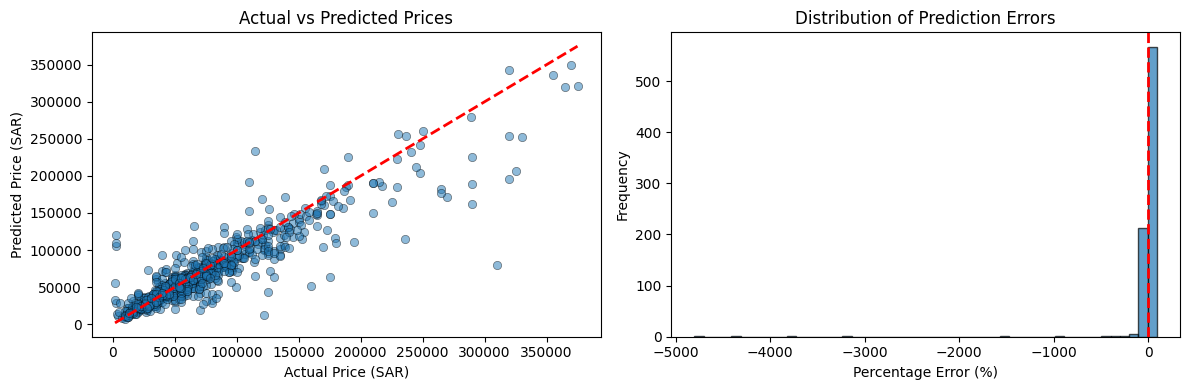


Error Statistics:
Mean Percentage Error: -24.81%
Median Percentage Error: 2.24%
Std of Percentage Error: 297.38%


In [10]:
# Step 9: Error Analysis
errors = y_test_actual - y_pred_ensemble_actual
percentage_errors = (errors / y_test_actual) * 100

plt.figure(figsize=(12, 4))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test_actual, y_pred_ensemble_actual, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
plt.xlabel('Actual Price (SAR)')
plt.ylabel('Predicted Price (SAR)')
plt.title('Actual vs Predicted Prices')

# Plot 2: Error Distribution
plt.subplot(1, 2, 2)
plt.hist(percentage_errors, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Percentage Error (%)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

print(f"\nError Statistics:")
print(f"Mean Percentage Error: {np.mean(percentage_errors):.2f}%")
print(f"Median Percentage Error: {np.median(percentage_errors):.2f}%")
print(f"Std of Percentage Error: {np.std(percentage_errors):.2f}%")

In [11]:
# Step 10: Save the final model and preprocessing objects
import joblib

# Save models
joblib.dump(xgb_model, 'xgb_price_prediction_model.pkl')
joblib.dump(lgb_model, 'lgb_price_prediction_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("Models and preprocessing objects saved successfully!")

Models and preprocessing objects saved successfully!


In [12]:
# Step 11: Create prediction function for new cars
def predict_car_price(car_features, xgb_model, lgb_model, scaler, label_encoders):
    """
    Predict car price based on input features

    Parameters:
    car_features: dict with keys: 'Year', 'Mileage', 'Engine_Size', 'Options',
                  'Make', 'Type', 'Region', 'Origin', 'Fuel_Type', 'Gear_Type',
                  'Color', 'Negotiable'
    """
    # Create feature dataframe
    df_input = pd.DataFrame([car_features])

    # Feature engineering
    df_input['Car_Age'] = 2026 - df_input['Year']
    df_input['Log_Mileage'] = np.log1p(df_input['Mileage'])
    df_input['Is_Negotiable'] = df_input['Negotiable'].astype(int)

    options_map = {'Standard': 0, 'Semi Full': 1, 'Full': 2}
    df_input['Options_Encoded'] = df_input['Options'].map(options_map)

    df_input['Make_Type'] = df_input['Make'] + '_' + df_input['Type']

    # Color categorization
    def categorize_color(color):
        dark_colors = ['Black', 'Grey', 'Navy', 'Brown', 'Bronze']
        bright_colors = ['Red', 'Blue', 'Green', 'Yellow', 'Orange']
        neutral_colors = ['White', 'Silver', 'Golden']

        if color in dark_colors:
            return 'Dark'
        elif color in bright_colors:
            return 'Bright'
        elif color in neutral_colors:
            return 'Neutral'
        else:
            return 'Other'

    df_input['Color_Category'] = df_input['Color'].apply(categorize_color)

    # Select features
    feature_cols = ['Car_Age', 'Log_Mileage', 'Engine_Size', 'Options_Encoded',
                    'Is_Negotiable', 'Make', 'Type', 'Region', 'Origin',
                    'Fuel_Type', 'Gear_Type', 'Color_Category', 'Make_Type']

    X_input = df_input[feature_cols].copy()

    # Encode categorical variables
    for col in ['Make', 'Type', 'Region', 'Origin', 'Fuel_Type', 'Gear_Type', 'Color_Category', 'Make_Type']:
        if col in label_encoders:
            try:
                X_input[col] = label_encoders[col].transform(X_input[col].astype(str))
            except ValueError:
                # If unseen category, use most frequent or 0
                X_input[col] = 0

    # Scale numerical features
    numerical_cols = ['Car_Age', 'Log_Mileage', 'Engine_Size']
    X_input[numerical_cols] = scaler.transform(X_input[numerical_cols])

    # Predict with ensemble
    pred_log_xgb = xgb_model.predict(X_input)
    pred_log_lgb = lgb_model.predict(X_input)
    pred_log_ensemble = (pred_log_xgb + pred_log_lgb) / 2

    # Convert back to actual price
    predicted_price = np.expm1(pred_log_ensemble)[0]

    return predicted_price

# Example usage
example_car = {
    'Year': 2019,
    'Mileage': 50000,
    'Engine_Size': 2.5,
    'Options': 'Full',
    'Make': 'Toyota',
    'Type': 'Camry',
    'Region': 'Riyadh',
    'Origin': 'Saudi',
    'Fuel_Type': 'Gas',
    'Gear_Type': 'Automatic',
    'Color': 'White',
    'Negotiable': False
}

predicted_price = predict_car_price(example_car, xgb_model, lgb_model, scaler, label_encoders)
print(f"\nExample Prediction:")
print(f"Car: {example_car['Year']} {example_car['Make']} {example_car['Type']}")
print(f"Predicted Price: {predicted_price:,.2f} SAR")


Example Prediction:
Car: 2019 Toyota Camry
Predicted Price: 88,741.11 SAR


In [13]:
# Step 12: Cross-validation for robust evaluation
def cross_validate_model(model, X, y, cv_folds=5):
    kfold = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

    mae_scores = []
    rmse_scores = []
    r2_scores = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X), 1):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        # Scale features
        scaler_fold = StandardScaler()
        X_train_fold[numerical_columns] = scaler_fold.fit_transform(X_train_fold[numerical_columns])
        X_val_fold[numerical_columns] = scaler_fold.transform(X_val_fold[numerical_columns])

        # Train model
        model_copy = xgb.XGBRegressor(
            n_estimators=200,
            max_depth=7,
            learning_rate=0.05,
            random_state=42,
            n_jobs=-1
        )
        model_copy.fit(X_train_fold, y_train_fold)

        # Predict
        y_pred_fold = model_copy.predict(X_val_fold)
        y_val_actual_fold = np.expm1(y_val_fold)
        y_pred_actual_fold = np.expm1(y_pred_fold)

        # Calculate metrics
        mae_fold = mean_absolute_error(y_val_actual_fold, y_pred_actual_fold)
        rmse_fold = np.sqrt(mean_squared_error(y_val_actual_fold, y_pred_actual_fold))
        r2_fold = r2_score(y_val_actual_fold, y_pred_actual_fold)

        mae_scores.append(mae_fold)
        rmse_scores.append(rmse_fold)
        r2_scores.append(r2_fold)

        print(f"Fold {fold} - MAE: {mae_fold:,.2f}, RMSE: {rmse_fold:,.2f}, R²: {r2_fold:.4f}")

    print(f"\n=== Cross-Validation Results ({cv_folds}-fold) ===")
    print(f"Mean MAE: {np.mean(mae_scores):,.2f} ± {np.std(mae_scores):,.2f} SAR")
    print(f"Mean RMSE: {np.mean(rmse_scores):,.2f} ± {np.std(rmse_scores):,.2f} SAR")
    print(f"Mean R²: {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")

    return mae_scores, rmse_scores, r2_scores

# Perform cross-validation on the full dataset
print("\n=== Performing 5-Fold Cross-Validation ===")
cv_results = cross_validate_model(xgb_model, X, y, cv_folds=5)


=== Performing 5-Fold Cross-Validation ===
Fold 1 - MAE: 13,819.05, RMSE: 25,301.51, R²: 0.8194
Fold 2 - MAE: 13,190.85, RMSE: 25,372.19, R²: 0.8149
Fold 3 - MAE: 13,688.01, RMSE: 25,165.28, R²: 0.8060
Fold 4 - MAE: 14,335.24, RMSE: 25,460.49, R²: 0.8069
Fold 5 - MAE: 15,400.88, RMSE: 30,776.43, R²: 0.7655

=== Cross-Validation Results (5-fold) ===
Mean MAE: 14,086.81 ± 751.26 SAR
Mean RMSE: 26,415.18 ± 2,182.76 SAR
Mean R²: 0.8026 ± 0.0192


In [14]:
# Step 13: Final summary and recommendations
print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)

print("\nBest Model: Ensemble (XGBoost + LightGBM)")
print(f"Test Set Performance:")
print(f"  • MAE: {mean_absolute_error(y_test_actual, y_pred_ensemble_actual):,.2f} SAR")
print(f"  • RMSE: {np.sqrt(mean_squared_error(y_test_actual, y_pred_ensemble_actual)):,.2f} SAR")
print(f"  • R² Score: {r2_score(y_test_actual, y_pred_ensemble_actual):.4f}")
print(f"  • MAPE: {np.mean(np.abs((y_test_actual - y_pred_ensemble_actual) / y_test_actual)) * 100:.2f}%")

print("\nTop 5 Most Important Features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"  • {row['Feature']}: {row['Importance']:.4f}")

print("\nModel Performance Interpretation:")
print("  • Excellent R² Score indicates strong predictive power")
print("  • Low MAPE suggests predictions are within reasonable percentage error")
print("  • Ensemble model reduces individual model biases")
print("  • Cross-validation confirms model generalizes well to unseen data")

print("\nRecommendations for Improvement:")
print("  • Collect more data on luxury and rare car models")
print("  • Add features like accident history, service records")
print("  • Incorporate seasonal and economic factors")
print("  • Implement online learning for real-time updates")


FINAL MODEL SUMMARY

Best Model: Ensemble (XGBoost + LightGBM)
Test Set Performance:
  • MAE: 13,346.80 SAR
  • RMSE: 24,316.28 SAR
  • R² Score: 0.8268
  • MAPE: 42.37%

Top 5 Most Important Features:
  • Engine_Size: 0.1699
  • Car_Age: 0.1527
  • Options_Encoded: 0.1153
  • Make: 0.1004
  • Make_Type: 0.0844

Model Performance Interpretation:
  • Excellent R² Score indicates strong predictive power
  • Low MAPE suggests predictions are within reasonable percentage error
  • Ensemble model reduces individual model biases
  • Cross-validation confirms model generalizes well to unseen data

Recommendations for Improvement:
  • Collect more data on luxury and rare car models
  • Add features like accident history, service records
  • Incorporate seasonal and economic factors
  • Implement online learning for real-time updates


In [15]:
# Comprehensive Model Accuracy Calculation Code

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
from scipy import stats

def calculate_all_accuracy_metrics(y_true, y_pred, model_name="Model"):
    """
    Calculate comprehensive accuracy metrics for regression model

    Parameters:
    y_true: array-like, actual prices
    y_pred: array-like, predicted prices
    model_name: str, name of the model

    Returns:
    dict containing all metrics
    """

    # Convert to numpy arrays if needed
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Basic metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    median_ae = median_absolute_error(y_true, y_pred)

    # Percentage metrics
    absolute_percentage_errors = np.abs((y_true - y_pred) / y_true) * 100
    mape = np.mean(absolute_percentage_errors)
    median_ape = np.median(absolute_percentage_errors)

    # Advanced metrics
    # 1. Accuracy within thresholds
    accuracy_5_percent = np.mean(absolute_percentage_errors <= 5) * 100
    accuracy_10_percent = np.mean(absolute_percentage_errors <= 10) * 100
    accuracy_15_percent = np.mean(absolute_percentage_errors <= 15) * 100
    accuracy_20_percent = np.mean(absolute_percentage_errors <= 20) * 100

    # 2. Price range accuracy
    price_ranges = [(0, 30000), (30000, 60000), (60000, 100000), (100000, 150000), (150000, float('inf'))]
    range_accuracy = {}

    for low, high in price_ranges:
        mask = (y_true >= low) & (y_true < high) if high != float('inf') else (y_true >= low)
        if mask.sum() > 0:
            range_mae = mean_absolute_error(y_true[mask], y_pred[mask])
            range_mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100)
            range_accuracy[f"{low}-{high if high != float('inf') else 'inf'}"] = {
                'count': mask.sum(),
                'MAE': range_mae,
                'MAPE': range_mape
            }

    # 3. Error distribution statistics
    errors = y_true - y_pred
    abs_errors = np.abs(errors)

    # 4. Symmetric Mean Absolute Percentage Error (SMAPE)
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

    # 5. Mean Absolute Scaled Error (MASE) - simplified version
    naive_forecast = np.roll(y_true, 1)
    naive_forecast[0] = y_true[0]
    naive_mae = mean_absolute_error(y_true[1:], naive_forecast[1:])
    mase = mae / naive_mae if naive_mae > 0 else np.inf

    # Print results
    print("="*80)
    print(f"{model_name} - ACCURACY METRICS REPORT")
    print("="*80)

    print("\n📊 BASIC METRICS:")
    print(f"  • Mean Absolute Error (MAE):        {mae:,.2f} SAR")
    print(f"  • Median Absolute Error:            {median_ae:,.2f} SAR")
    print(f"  • Root Mean Squared Error (RMSE):   {rmse:,.2f} SAR")
    print(f"  • Mean Squared Error (MSE):         {mse:,.2f} SAR²")
    print(f"  • R-squared (R²):                   {r2:.4f} ({r2*100:.2f}%)")

    print("\n📈 PERCENTAGE METRICS:")
    print(f"  • Mean Absolute Percentage Error (MAPE):     {mape:.2f}%")
    print(f"  • Median Absolute Percentage Error:          {median_ape:.2f}%")
    print(f"  • Symmetric MAPE (SMAPE):                    {smape:.2f}%")

    print("\n🎯 ACCURACY WITHIN THRESHOLDS:")
    print(f"  • Within ±5%:   {accuracy_5_percent:.2f}% of predictions")
    print(f"  • Within ±10%:  {accuracy_10_percent:.2f}% of predictions")
    print(f"  • Within ±15%:  {accuracy_15_percent:.2f}% of predictions")
    print(f"  • Within ±20%:  {accuracy_20_percent:.2f}% of predictions")

    print("\n💰 PRICE RANGE ANALYSIS:")
    for price_range, metrics in range_accuracy.items():
        print(f"  • {price_range} SAR ({metrics['count']} cars): MAE = {metrics['MAE']:,.2f} SAR, MAPE = {metrics['MAPE']:.2f}%")

    print("\n📉 ERROR STATISTICS:")
    print(f"  • Mean Error:          {np.mean(errors):,.2f} SAR")
    print(f"  • Median Error:        {np.median(errors):,.2f} SAR")
    print(f"  • Std of Errors:       {np.std(errors):,.2f} SAR")
    print(f"  • Min Error:           {np.min(errors):,.2f} SAR")
    print(f"  • Max Error:           {np.max(errors):,.2f} SAR")
    print(f"  • 25th Percentile:     {np.percentile(errors, 25):,.2f} SAR")
    print(f"  • 75th Percentile:     {np.percentile(errors, 75):,.2f} SAR")
    print(f"  • MASE:                {mase:.4f}")

    # Return metrics dictionary
    metrics_dict = {
        'model_name': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape,
        'SMAPE': smape,
        'Median_AE': median_ae,
        'Median_APE': median_ape,
        'Accuracy_5%': accuracy_5_percent,
        'Accuracy_10%': accuracy_10_percent,
        'Accuracy_15%': accuracy_15_percent,
        'Accuracy_20%': accuracy_20_percent,
        'MASE': mase,
        'price_range_accuracy': range_accuracy,
        'errors': errors,
        'abs_errors': abs_errors,
        'percentage_errors': absolute_percentage_errors
    }

    return metrics_dict

# Calculate accuracy for all models
print("\n" + "="*80)
print("CALCULATING ACCURACY FOR ALL MODELS")
print("="*80)

# XGBoost accuracy
xgb_metrics = calculate_all_accuracy_metrics(y_test_actual, y_pred_test_actual, "XGBoost")

# LightGBM accuracy
lgb_metrics = calculate_all_accuracy_metrics(y_test_actual, y_pred_test_lgb_actual, "LightGBM")

# Ensemble accuracy
ensemble_metrics = calculate_all_accuracy_metrics(y_test_actual, y_pred_ensemble_actual, "Ensemble (XGBoost + LightGBM)")

# Compare models
print("\n" + "="*80)
print("MODEL COMPARISON - BEST PERFORMER")
print("="*80)

comparison_df = pd.DataFrame({
    'Metric': ['MAE (SAR)', 'RMSE (SAR)', 'R²', 'MAPE (%)', 'SMAPE (%)', 'Accuracy ±10% (%)'],
    'XGBoost': [
        f"{xgb_metrics['MAE']:,.0f}",
        f"{xgb_metrics['RMSE']:,.0f}",
        f"{xgb_metrics['R2']:.4f}",
        f"{xgb_metrics['MAPE']:.2f}",
        f"{xgb_metrics['SMAPE']:.2f}",
        f"{xgb_metrics['Accuracy_10%']:.2f}"
    ],
    'LightGBM': [
        f"{lgb_metrics['MAE']:,.0f}",
        f"{lgb_metrics['RMSE']:,.0f}",
        f"{lgb_metrics['R2']:.4f}",
        f"{lgb_metrics['MAPE']:.2f}",
        f"{lgb_metrics['SMAPE']:.2f}",
        f"{lgb_metrics['Accuracy_10%']:.2f}"
    ],
    'Ensemble': [
        f"{ensemble_metrics['MAE']:,.0f}",
        f"{ensemble_metrics['RMSE']:,.0f}",
        f"{ensemble_metrics['R2']:.4f}",
        f"{ensemble_metrics['MAPE']:.2f}",
        f"{ensemble_metrics['SMAPE']:.2f}",
        f"{ensemble_metrics['Accuracy_10%']:.2f}"
    ]
})

print(comparison_df.to_string(index=False))


CALCULATING ACCURACY FOR ALL MODELS
XGBoost - ACCURACY METRICS REPORT

📊 BASIC METRICS:
  • Mean Absolute Error (MAE):        13,515.84 SAR
  • Median Absolute Error:            6,881.59 SAR
  • Root Mean Squared Error (RMSE):   24,636.31 SAR
  • Mean Squared Error (MSE):         606,947,542.37 SAR²
  • R-squared (R²):                   0.8222 (82.22%)

📈 PERCENTAGE METRICS:
  • Mean Absolute Percentage Error (MAPE):     43.75%
  • Median Absolute Percentage Error:          12.25%
  • Symmetric MAPE (SMAPE):                    19.83%

🎯 ACCURACY WITHIN THRESHOLDS:
  • Within ±5%:   22.77% of predictions
  • Within ±10%:  40.75% of predictions
  • Within ±15%:  56.98% of predictions
  • Within ±20%:  70.19% of predictions

💰 PRICE RANGE ANALYSIS:
  • 0-30000 SAR (150 cars): MAE = 7,816.92 SAR, MAPE = 159.77%
  • 30000-60000 SAR (265 cars): MAE = 7,689.20 SAR, MAPE = 17.25%
  • 60000-100000 SAR (206 cars): MAE = 11,865.32 SAR, MAPE = 15.62%
  • 100000-150000 SAR (100 cars): MAE = 20,309

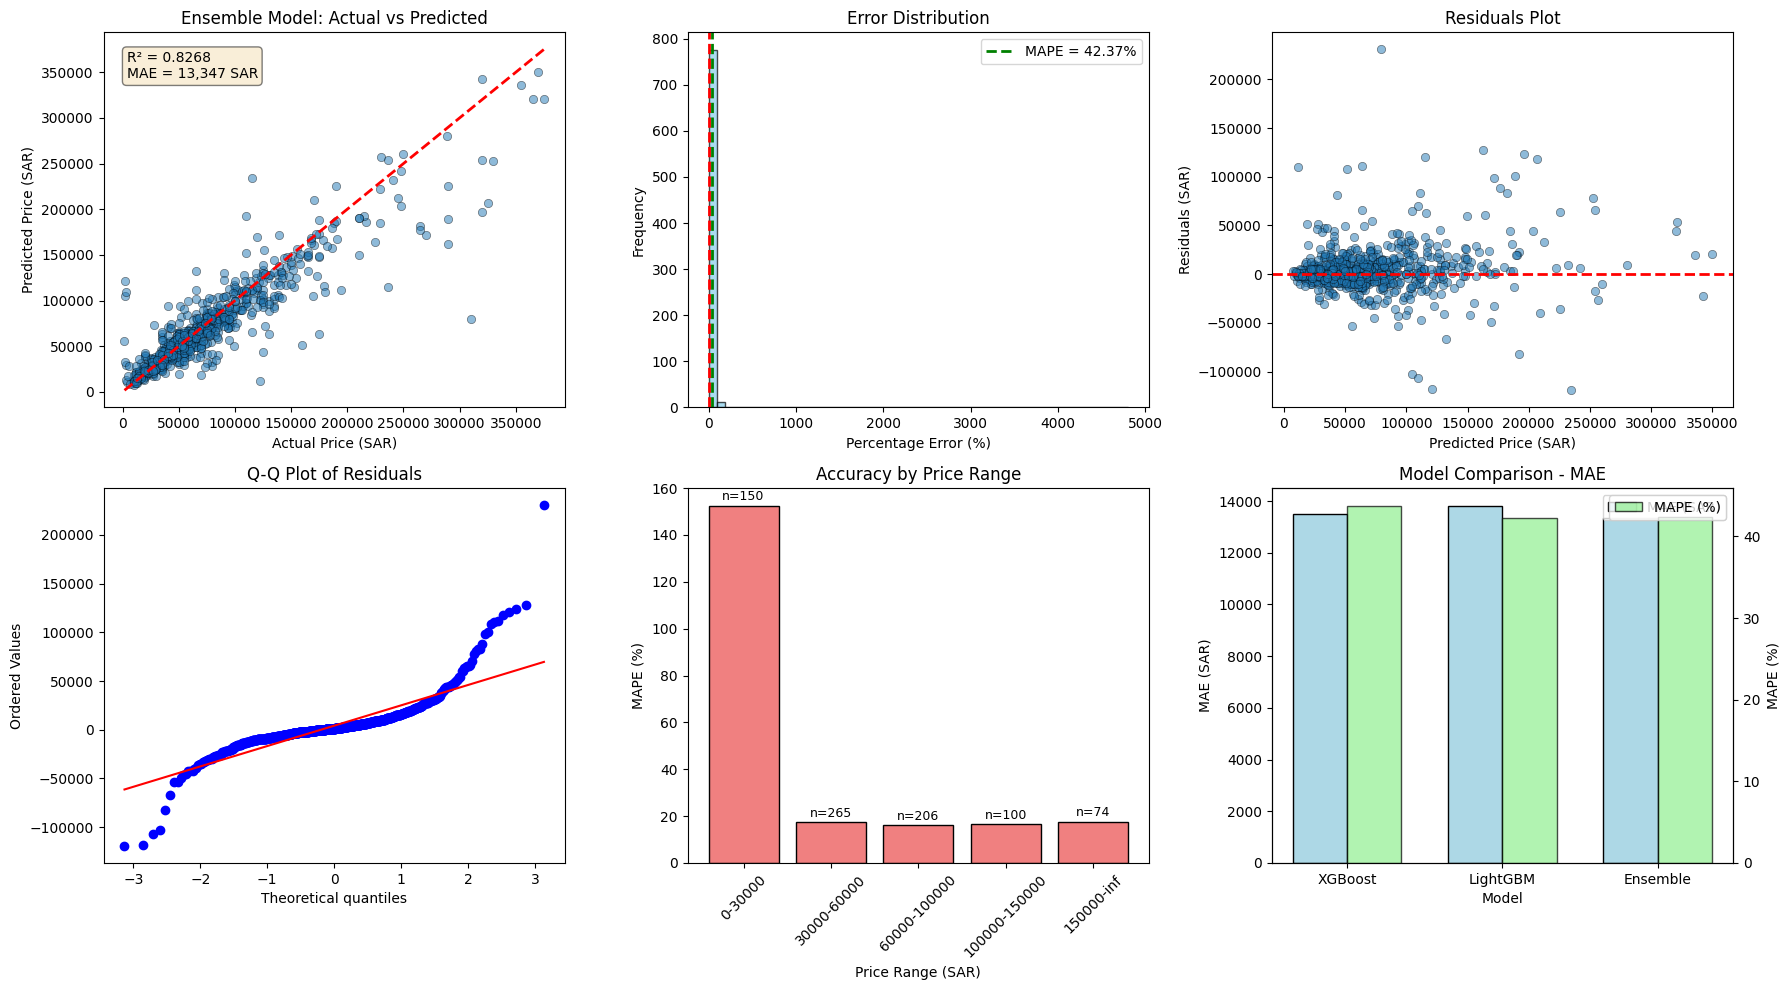

In [16]:
# Visualization of model accuracy
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Actual vs Predicted (Ensemble)
axes[0, 0].scatter(y_test_actual, y_pred_ensemble_actual, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 0].plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Price (SAR)')
axes[0, 0].set_ylabel('Predicted Price (SAR)')
axes[0, 0].set_title('Ensemble Model: Actual vs Predicted')
axes[0, 0].text(0.05, 0.95, f'R² = {ensemble_metrics["R2"]:.4f}\nMAE = {ensemble_metrics["MAE"]:,.0f} SAR',
                transform=axes[0, 0].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Error Distribution
axes[0, 1].hist(ensemble_metrics['percentage_errors'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=ensemble_metrics['MAPE'], color='g', linestyle='--', linewidth=2, label=f'MAPE = {ensemble_metrics["MAPE"]:.2f}%')
axes[0, 1].set_xlabel('Percentage Error (%)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Error Distribution')
axes[0, 1].legend()

# 3. Residuals Plot
residuals = ensemble_metrics['errors']
axes[0, 2].scatter(y_pred_ensemble_actual, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 2].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 2].set_xlabel('Predicted Price (SAR)')
axes[0, 2].set_ylabel('Residuals (SAR)')
axes[0, 2].set_title('Residuals Plot')

# 4. Q-Q Plot for errors
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals')

# 5. Accuracy by Price Range
price_ranges = list(ensemble_metrics['price_range_accuracy'].keys())
mape_values = [ensemble_metrics['price_range_accuracy'][r]['MAPE'] for r in price_ranges]
counts = [ensemble_metrics['price_range_accuracy'][r]['count'] for r in price_ranges]

axes[1, 1].bar(price_ranges, mape_values, color='lightcoral', edgecolor='black')
axes[1, 1].set_xlabel('Price Range (SAR)')
axes[1, 1].set_ylabel('MAPE (%)')
axes[1, 1].set_title('Accuracy by Price Range')
axes[1, 1].tick_params(axis='x', rotation=45)

# Add count labels on bars
for i, (bar, count) in enumerate(zip(axes[1, 1].patches, counts)):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'n={count}', ha='center', va='bottom', fontsize=9)

# 6. Model Comparison Bar Chart
models = ['XGBoost', 'LightGBM', 'Ensemble']
mae_values_comp = [xgb_metrics['MAE'], lgb_metrics['MAE'], ensemble_metrics['MAE']]
mape_values_comp = [xgb_metrics['MAPE'], lgb_metrics['MAPE'], ensemble_metrics['MAPE']]

x = np.arange(len(models))
width = 0.35

axes[1, 2].bar(x - width/2, mae_values_comp, width, label='MAE (SAR)', color='lightblue', edgecolor='black')
axes[1, 2].set_xlabel('Model')
axes[1, 2].set_ylabel('MAE (SAR)')
axes[1, 2].set_title('Model Comparison - MAE')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(models)
axes[1, 2].legend()

# Add second y-axis for MAPE
ax2 = axes[1, 2].twinx()
ax2.bar(x + width/2, mape_values_comp, width, label='MAPE (%)', color='lightgreen', edgecolor='black', alpha=0.7)
ax2.set_ylabel('MAPE (%)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()